<a href="https://colab.research.google.com/github/deepkkumar07/Machine-Learning-Projects/blob/main/Unsupervised_ML(K_mean)/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
# importing important libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')


In [22]:
#Loading Dataset from drive
df= pd.read_csv('/content/drive/MyDrive/machine learning/Mall_Customers.csv')

In [23]:
#dataset
df.head(10)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [24]:
df.shape

(200, 5)

In [25]:
df.isnull().sum()  # checking if there is any null value in data set

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [26]:
df.info() # information of data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [27]:
# dropping Customerid from dataset as uinique identifier donot have any predictive powers
df.drop('CustomerID', axis = 1, inplace = True)

In [35]:
# dataset after removing the customer id column
df

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [44]:
# normalizing the feature
from sklearn.preprocessing import StandardScaler, normalize
X = df.iloc[:, 2:4].values # Columns of intereset
sc = StandardScaler()
X = sc.fit_transform(X) # Normalizing the data
X = normalize(X)
print(X)

[[-0.97013572 -0.24256276]
 [-0.82401048  0.56657455]
 [-0.7039784  -0.71022139]
 [-0.85305371  0.52182312]
 [-0.97279192 -0.23168055]
 [-0.85658242  0.51601024]
 [-0.68749685 -0.72618736]
 [-0.69078646  0.72305883]
 [-0.65452065 -0.75604412]
 [-0.88229014  0.47070597]
 [-0.74851489 -0.66311798]
 [-0.64199257  0.76671086]
 [-0.74971714 -0.66175843]
 [-0.82998676  0.55778309]
 [-0.73123898 -0.68212137]
 [-0.81069137  0.58547374]
 [-0.93140492 -0.36398472]
 [-0.92647723  0.37635083]
 [-0.86725326 -0.49786723]
 [-0.61137179  0.7913435 ]
 [-0.92103954 -0.38946909]
 [-0.84445476  0.53562689]
 [-0.61183513 -0.79098532]
 [-0.83762959  0.54623866]
 [-0.66245749 -0.74909951]
 [-0.70946363  0.70474205]
 [-0.86933095 -0.49423041]
 [-0.94753177  0.3196616 ]
 [-0.85037495 -0.52617719]
 [-0.64462638  0.76449777]
 [-0.54520069 -0.83830556]
 [-0.79661478  0.6044873 ]
 [-0.50591796 -0.8625816 ]
 [-0.54395835  0.83911222]
 [-0.59925019 -0.80056181]
 [-0.6605323   0.75079763]
 [-0.61823317 -0.78599475]
 

# Train the Model

In [40]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.metrics import silhouette_score

In [51]:
def silhouette_analysis(n):
  for n_clusters in range(2,n):
    km = KMeans(n_clusters = n_clusters) #instantiate the kmean class
    pred = km.fit_predict(X) # .fit , .predict
    center = km.cluster_centers_


    score = silhouette_score(X, pred, metric = 'euclidean')
    print("For n_clusters = {}, silhouette score is {})".format(n_clusters, score))

In [52]:
silhouette_analysis(10)

For n_clusters = 2, silhouette score is 0.45207272118383485)
For n_clusters = 3, silhouette score is 0.6032007063012638)
For n_clusters = 4, silhouette score is 0.6616413670429191)
For n_clusters = 5, silhouette score is 0.621808509509034)
For n_clusters = 6, silhouette score is 0.5932920412415835)
For n_clusters = 7, silhouette score is 0.5577972420191947)
For n_clusters = 8, silhouette score is 0.5676200951774625)
For n_clusters = 9, silhouette score is 0.5703397700518557)


In [54]:
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42, n_init=10)
y_kmeans = kmeans.fit_predict(X)


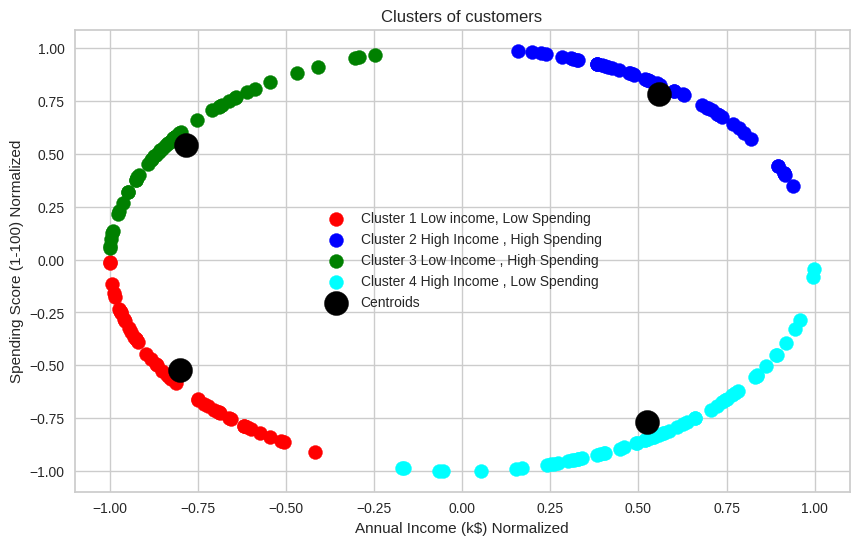

In [58]:
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1 Low income, Low Spending')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2 High Income , High Spending')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3 Low Income , High Spending')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4 High Income , Low Spending ')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'black', label = 'Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$) Normalized')
plt.ylabel('Spending Score (1-100) Normalized')
plt.legend()
plt.show()